In [22]:
import pandas as pd
df=pd.read_csv('data.csv')


In [5]:
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [11]:
df['Dosage']

0                  NaN
1              10mg/ml
2                  NaN
3                150mg
4                 30mg
             ...      
10319       30/50/60mg
10320        150/300mg
10321    600/300/300mg
10322        150/300mg
10323          30/60mg
Name: Dosage, Length: 10324, dtype: object

In [8]:
df['Weight (Kilograms)']

0                                13
1                               358
2                               171
3                              1855
4                              7590
                    ...            
10319       See DN-4307 (ID#:83920)
10320       See DN-4313 (ID#:83921)
10321    Weight Captured Separately
10322                          1392
10323    Weight Captured Separately
Name: Weight (Kilograms), Length: 10324, dtype: object

In [12]:
df['PQ First Sent to Client Date']

0        Pre-PQ Process
1        Pre-PQ Process
2        Pre-PQ Process
3        Pre-PQ Process
4        Pre-PQ Process
              ...      
10319          10/16/14
10320          10/24/14
10321           8/12/14
10322            7/1/15
10323          10/16/14
Name: PQ First Sent to Client Date, Length: 10324, dtype: object

In [13]:
df['Freight Cost (USD)']

0                                    780.34
1                                    4521.5
2                                   1653.78
3                                  16007.06
4                                  45450.08
                        ...                
10319               See DN-4307 (ID#:83920)
10320               See DN-4313 (ID#:83921)
10321    Freight Included in Commodity Cost
10322    Freight Included in Commodity Cost
10323    Freight Included in Commodity Cost
Name: Freight Cost (USD), Length: 10324, dtype: object

In [14]:
df.isna().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [16]:
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')
df['Shipment Mode']

0          Air
1          Air
2          Air
3          Air
4          Air
         ...  
10319    Truck
10320    Truck
10321    Truck
10322    Truck
10323    Truck
Name: Shipment Mode, Length: 10324, dtype: object

In [33]:
df['Line Item Insurance (USD)'].mean()
df['Line Item Insurance (USD)'].median()
df['Line Item Insurance (USD)'].fillna(df['Line Item Insurance (USD)'].median(), inplace=True)
df['Line Item Insurance (USD)']

0          47.04
1          47.04
2          47.04
3          47.04
4          47.04
          ...   
10319     705.79
10320     161.71
10321    5284.04
10322     134.03
10323      85.82
Name: Line Item Insurance (USD), Length: 10324, dtype: float64

In [40]:
df.columns
df['Scheduled Delivery Date'] = pd.to_datetime(df['Scheduled Delivery Date'])
df['Scheduled Delivery Date']

0       2006-06-02
1       2006-11-14
2       2006-08-27
3       2006-09-01
4       2006-08-11
           ...    
10319   2015-07-31
10320   2015-07-31
10321   2015-08-31
10322   2015-09-09
10323   2015-08-31
Name: Scheduled Delivery Date, Length: 10324, dtype: datetime64[ns]

In [42]:
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,47.04
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,47.04
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,47.04
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,47.04
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,47.04


In [46]:
df.groupby('Country')['Project Code'].count()

Country
Afghanistan              3
Angola                   7
Belize                   1
Benin                   13
Botswana                70
Burkina Faso             2
Burundi                 98
Cameroon                75
Congo, DRC             333
Côte d'Ivoire         1083
Dominican Republic      52
Ethiopia               216
Ghana                   58
Guatemala               15
Guinea                   1
Guyana                 237
Haiti                  655
Kazakhstan               2
Kenya                  111
Kyrgyzstan               2
Lebanon                  8
Lesotho                  4
Liberia                  6
Libya                    8
Malawi                  14
Mali                    17
Mozambique             631
Namibia                 95
Nigeria               1194
Pakistan                15
Rwanda                 430
Senegal                  3
Sierra Leone             4
South Africa          1406
South Sudan            164
Sudan                   46
Swaziland           

In [55]:
import matplotlib.pyplot as plt
df.groupby('Country')['Project Code'].count().mean()

np.float64(240.09302325581396)

<Axes: xlabel='Country', ylabel='Project Code'>

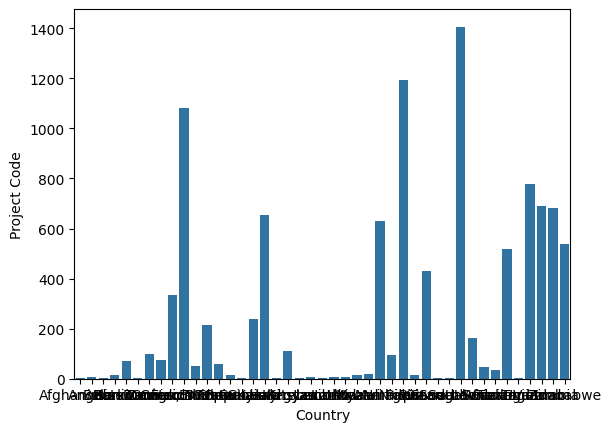

In [57]:
# plt.bar(df.groupby('Country')['Project Code'].count(), height=)
import seaborn as sns
sns.barplot(df.groupby('Country')['Project Code'].count())